# Simulação computacional do decaimento de átomos e análise estatística dos resultados

## Introdução:

##### O decaimento radioativo é um fenômeno nuclear no qual átomos instáveis emitem radiação e se transformam em outros elementos ao longo do tempo. Embora o comportamento generalizado de uma grande quantidade de átomos seja descrito pela lei do decaimento exponencial, o decaimento de cada átomo individual ocorre de forma aleatória e não pode ser determinado com certeza, e assim, é regido por probabilidades. 
##### A Lei para grande quantidades de átomos é: N(t)=N0e^(−λt), onde N0 é o número inicial de átomos do sistema, λ é a constante de decaimento (que equivale à probabilidade de decaimento por unidade de tempo) e t é o tempo. A meia-vida é o tempo necessário para que metade dos átomos decaia em um sistema, e pode ser descrita pela fórmula: t1/2 = ln(2) / λ

## Objetivos:
##### O objetivo deste projeto é desenvolver um simulador computacional do decaimento radioativo em Python, capaz de mostrar o processo aleatório de decaimento átomo a átomo, conseguir simular diferentes resultados para as mesmas entradas e comparar os resultados com a teoria.

##### Além disso, o trabalho busca implementar os resultados gráficamente, para que o estudo dessas simulações seja feito estatisticamente. O uso de diversas funções também é essencial para o funcionamento da simulação. E por fim, para construir um programa mais interativo, a implementação de uma interface gráfica é crucial para que o usuário possa criar o seu próprio experimento.



## Metodologia:

##### A ideia do simulador é: a cada segundo de simulação, cada átomo ainda presente sorteia um número aleatório x distribuído no intervalo [0, 1). Se x < λ, ou seja, menor que a probabilidade dada pelo usuário, o átomo decai; se x > λ, ele permanece no sistema. Esse processo é repetido para todos os átomos e para cada intervalo de tempo, até o fim da simulação (Função simulacao(atomos,prob,segundos) realiza esse modelo).

##### Porém, para obtermos resultados realmente estatisticos e avaliar as probabilidades, utilizamos o programa para rodar diversas vezes a simulação, e isso é feito pela função varias_simulacoes(qtd, atomos, prob, segundos) que executa as n simulações, coletando o valor final de cada uma das simulações, e com esses valores, ela analisa os dados das execuções e retorna os dados estatisticos.

##### Em relação a interface, ela foi estruturada em quatro telas construídas com frames do Tkinter.A navegação entre telas é feita por botões, utilizando os métodos pack() e pack_forget() para exibir e ocultar os frames. As entradas inseridas na Tela 1 são convertidas para variáveis globais e reutilizadas nas telas seguintes. A Tela 2 possui um gráfico animado do Matplotlib dentro da janela Tkinter via FigureCanvasTkAgg, exibindo o decaimento experimental e teórico simultaneamente.

## Discussão dos resultados:

##### Utilizando os valores de referência N0 = 100 átomos, λ = 0,1 e t = 10 s, o valor teórico esperado ao final da simulação é N(10) = 100 · e−1, que é aproximadamente igual a 36,8 átomos. As simulações realizadas por este projeto produziram valores próximos a esse resultado, com divergencias decorrentes da natureza probabilistica e aleatória do modelo.

##### Nessa lógica, a curva teórica e a curva experimental do gráfico se aproximam à medida que N0 aumenta. Para N0 = 1000 ou mais, as duas curvas tornam-se praticamente iguais, enquanto para N0 pequeno (por exemplo, N0 = 10) as diferenças aleatórias são proporcionalmente maiores e causam distanciamento entre as duas curvas. Tais práticas são coerentes com a ideia desse modelo na realidade. 

#### Parte 1: Simulação --> decaimento de átomos ao longo do tempo

##### nessa parte, foi importado todas as bibliotecas que serão utilizadas ao longo do projeto e foi definida a função simulacao(atomos,prob,segundos) para conseguirmos analisar quantos atomos decaem em um sistema ao longo de um tempo escolhido pelo usuário

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.animation import FuncAnimation
import random as rd
import tkinter as tk
from tkinter import messagebox

def simulacao(atomos,prob,segundos):
    """
    função principal que testa se cada atomo decai ou não usando a biblioteca random

    Parâmetros:
    atomos (int): numero de atomos que o sistema terá inicialmente
    prob (float): a probabilidade a ser usada no sistema para o decaimento
    segundos(int): quanto tempo o sistema sera observado

    Retorna:
    uma lista que mostra quantos atomos não decairam a cada segundo da simulação
    
    """
    if prob < 0 or prob > 1:
        return "ERRO! A probabilidade deve estar entre 0 e 1"
        
    resultado = []
    resultado.append(atomos) #lista que guarda os resultados
    
    for segundo in range(segundos): # quantas vezes o decaimento roda
        decaidos = 0
        for i in range(atomos): #para cada atomo
            numero_aleatorio = rd.random() # gera uma probabilidade de decair para cada atomo
            if numero_aleatorio < prob: # se essa probabilidade de decair é menor do que
                decaidos = decaidos + 1         # a probabilidade dada pelo usuario, então esse atomo
                                                # decai, caso contrario ele continua igual
        atomos = atomos - decaidos
        resultado.append(atomos)
    return resultado # a lista mostra quantos atomos não decairam a cada passo, e sempre é aleatório

#### Gráficos dessa simulação e comparação com a teoria

##### Nesta próxima célula, é pedido ao usuário os inputs para o gráfico da função simulacao(atomos,prob,segundos) e depois disso é plotado o grafico com a linha do experimento, a linha teorica e a linha demonstrando a meia vida experimental

Digite o número inicial de átomos no sistema:  100
Digite a probabilidade de decaimento de cada partícula:  0.2
Digite a quantidade de segundos:  1


Meia-vida experimental aproximada: 3.465735902799726 segundos


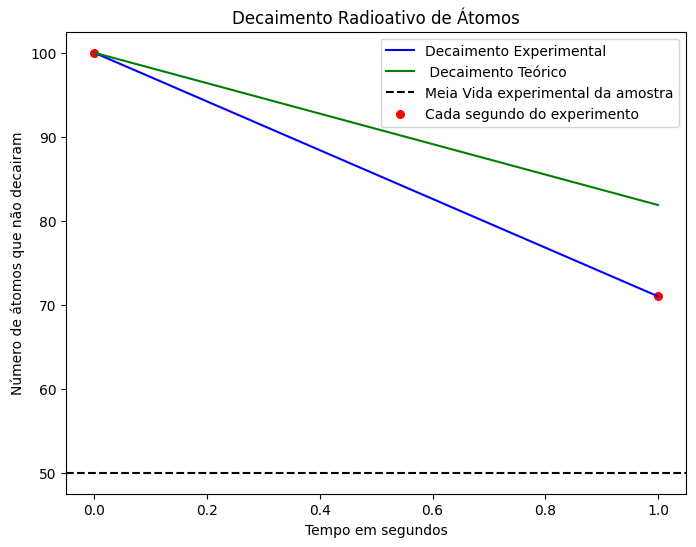

In [29]:
atomos = int(input("Digite o número inicial de átomos no sistema: "))
prob = float(input("Digite a probabilidade de decaimento de cada partícula: "))
segundos = int(input("Digite a quantidade de segundos: "))
# inputs para o usuario colocar e ser aplicado na função anterior

dados = simulacao(atomos, prob, segundos)

plt.figure(figsize=(8,6)) # tamanho do grafico
plt.title("Decaimento Radioativo de Átomos") # titulo do grafico
plt.xlabel("Tempo em segundos") # eixo x do grafico
plt.ylabel("Número de átomos que não decairam") # eixo y do grafico

plt.plot(dados, label="Decaimento Experimental", color='blue') # cor da linha do grafico
plt.legend(loc='upper right') #legenda

t = np.arange(len(dados)) 
teorico = dados[0] * np.exp(-(prob) * t) #formula de decaimento na teoria
plt.plot(teorico, label=" Decaimento Teórico", color = "green")
plt.legend(loc='upper right')

plt.axhline(dados[0]/2, color='black', # linha que mostra a meia vida da amostra
            linestyle='--', label='Meia Vida experimental da amostra')
meia_vida = np.log(2) / prob
print("Meia-vida experimental aproximada:", meia_vida, "segundos")

plt.scatter(range(len(dados)), dados, label="Cada segundo do experimento", color='red', s=30) 
# pontos que reforçam cada segundo
plt.legend(loc='upper right')

plt.show()

#### Parte 2: Experimento --> repetir a simulação várias vezes e gerar conjunto de dados

##### Nesta função, é pedido novamente os parametros da função simulacao(atomos,prob,segundos) e um novo parametro é visto, sendo esse a quantidade x de vezes que a função simulacao(atomos,prob,segundos) deve rodar, assim retornando uma lista com os atomos que sobraram ao fim de cada simulação

In [14]:
def varias_simulacoes(qtd, atomos, prob, segundos):
    """
    função que roda x vezes (quantidade estabelecida pelo usuário) a função simulacao definida 
    anteriormente

    Parâmetros:
    qtd (int): quantidade de vezes que a simulação irá rodar 
    atomos (int): numero de atomos que o sistema terá inicialmente
    prob (float): a probabilidade a ser usada no sistema para o decaimento
    segundos(int): quanto tempo o sistema sera observado

    Retorna:
    uma lista que mostra quantos atomos não decairam ao fim de cada simulação
    
    """
    resultados_finais = [] # lista criada para guardar o valor final de cada simulação
    
    for i in range(qtd):
        dados = simulacao(atomos, prob, segundos) #roda uma simulação
        valor_final = dados[-1] # numero final de atomos para cada simulação
        resultados_finais.append(valor_final) #coloca cada valor final em uma lista

    return resultados_finais 
# aqui tem todos os atomos sobrando nas condições estabelecidas ao fim de cada programa

#### Parte 3: Análise --> pegar a média, desvio padrão, histograma, etc

##### Aqui temos duas funções que recolhem valores estatisticos da lista retornada pela função varias_simulacoes(qtd, atomos, prob, segundos) e retornam a média, o desvio padrão, o valor minimo, o valor maximo e um histograma com a frequencia de cada valor na lista.

In [26]:
def analisar_resultados(resultados):
    """
    função que analise os resultados da lista resultante da função varias_simulacoes
    (resultados finais)

    Parâmetros:
    resultados(list): lista com a quantidade de atomos que não decairam ao decorrer de x simulções

    Retorna:
    a média, o desvio padrão, o valor minimo e o valor máximo dos números na lista da entrada
    
    """
    
    media = np.mean(resultados) # media dos resultados das simulações
    desvio = np.std(resultados) # desvio padrão dos resultados das simulações
    minimo = np.min(resultados) # valor minimo dos resultados das simulações
    maximo = np.max(resultados) # valor maximo dos resultados das simulações
    return {
    "media":  media,
    "desvio": desvio,
    "minimo": minimo,
    "maximo": maximo
}

def plotar_histograma(resultados):
    """
    função que plota um histograma com base nos resultados da função varias_simulacoes 
    (resultados finais)

    Parâmetros:
    resultados(list): lista com a quantidade de atomos que não decairam ao decorrer de x simulções

    Retorna:
    um grafico no formato de histograma da frequencia de cada valor na lista da entrada
    
    """
    
    plt.figure()
    plt.hist(resultados, color='skyblue', edgecolor='black') #plota o histograma

    plt.title("Distribuição dos resultados finais") #titulo
    plt.xlabel("Número de átomos restantes") #eixo x
    plt.ylabel("Frequência") #eixo y

    plt.grid(True) #coloca grade
    plt.show()

#### Parte 4: Interface --> com o tkinter, terá a implementação de uma interface gráfica

##### essa parte da interface ficou mais longa do que as outras partes para não quebrar o codigo usando o tkinter em mais de uma célula, já que isso pode causar problema com essa biblioteca. Na primeira parte do codigo, podemos observar a definições de funções para mostrar alguma tela e esconder as outras. Após isso, vemos a programação de cada parte dividida nas 4 telas. Assim observamos a tela 1 como sendo o lugar para colocar as entradas, a tela 2 sendo essencialmente utilizada para mostrar o grafico, a tela 3 tendo a entrada da quantidade de simulações desejada pelo usuário, e a tela 4 possui as informações estatisticas. 

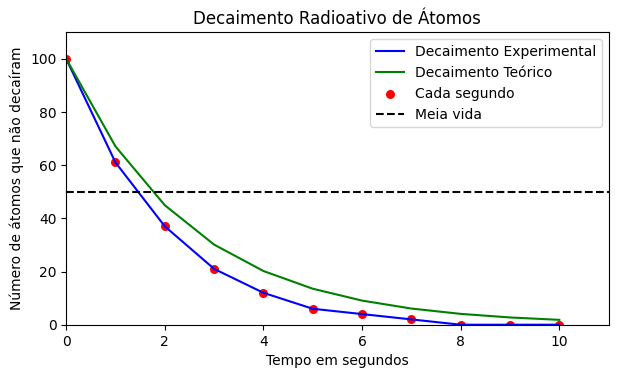

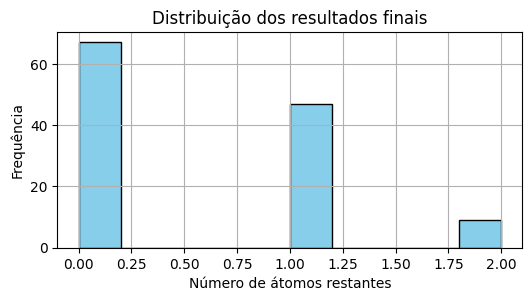

In [31]:
import tkinter as tk

janela = tk.Tk() # lugar(container) em que todos os meus elementos serão feitos
janela.title("Simulador de decaimento radioativo") # titulo da janela
janela.geometry("800x600") # regula o tamanho da janela 
janela.configure(bg="#1b2e45") #escolhe a cor de fundo
anim = None

# cada função abaixo esconde todas as telas e exibe só a que queremos
# pack() exibe o frame na janela / pack_forget() esconde sem destruir

def ir_para_tela1():
    
    """
    função que serve para mostrar a tela 1 e esconder as demais telas
    
    """
    tela1.pack()        # exibe a tela 1
    tela2.pack_forget() # esconde a tela 2
    tela3.pack_forget() # esconde a tela 3
    tela4.pack_forget() # esconde a tela 4
    
def ir_para_tela2():
    
    """
    função que serve para mostrar a tela 2 e esconder as demais telas, alem de recolher os valores 
    de entrada da primeira tela e defini-los em variaveis e torna-las globais.
    
    """
    # le os valores das entradas da tela anterior no momento do clique para a tela seguinte
    try:
        atomos   = int(entrada1.get())    # pega o texto da entrada e converte para inteiro
        prob     = float(entrada2.get())  # pega o texto da entrada e converte para decimal
        segundos = int(entrada3.get())    # pega o texto da entrada e converte para inteiro
        #foram criadas variaveis locais na função 
    except ValueError:
        # se o usuario digitou algo que nao e numero, mostra um aviso de erro e para aqui
        messagebox.showerror("Erro", "Preencha todos os campos com números válidos.") 
        #função do próprio tkinter para mostar uma caixa com o erro
        return  # sai da função sem trocar de tela

    if prob < 0 or prob > 1:
        messagebox.showerror("Erro", "A probabilidade deve estar entre 0 e 1.")
        return

    
    # guarda os valores em variaveis globais para as outras telas poderem usar, ja que eram locais
    global g_atomos, g_prob, g_segundos, g_dados
    g_atomos   = atomos
    g_prob     = prob
    g_segundos = segundos
    g_dados    = simulacao(atomos, prob, segundos)  # roda a simulação e salva o resultado
    
    desenhar_grafico()   # atualiza o grafico com os novos dados antes de exibir a tela 2
    
    tela1.pack_forget()
    tela2.pack()
    tela3.pack_forget()
    tela4.pack_forget()
    
def ir_para_tela3():
    
    """
    função que serve para mostrar a tela 3 e esconder as demais telas
    
    """
    tela1.pack_forget() # esconde a tela 1
    tela2.pack_forget() # esconde a tela 2
    tela3.pack()        # exibe a tela 3
    tela4.pack_forget() # esconde a tela 4
    
def ir_para_tela4():
    
    """
    função que serve para mostrar a tela 4 e esconder as demais telas, alem de recolher o valor 
    de entrada da tela anterior e defini-lo em uma variavel e torna-la global.
    
    """
    try:
        qtd = int(entrada4.get())
    except ValueError:
        messagebox.showerror("Erro", "Digite um número inteiro de simulações.")
        return  # sai sem trocar de tela se der erro
 
    global g_resultados
    g_resultados = varias_simulacoes(qtd, g_atomos, g_prob, g_segundos)
 
    atualizar_tela4()  # preenche os dados antes de exibir a tela
 
    # só troca de tela depois que tudo deu certo
    tela1.pack_forget()
    tela2.pack_forget()
    tela3.pack_forget()
    tela4.pack()

# Tela 1
tela1 = tk.Frame(janela, bg="#1b2e45") #azul escuro
tela1.pack(padx=10, pady=10) 

texto1 = tk.Label(tela1, text="Digite as informações abaixo:", font=("Arial", 20, "bold"),
                  fg="white", bg="#1b2e45")
texto1.pack(pady=10)
linha1 = tk.Frame(tela1, bg="#00c9a7", height=2)
linha1.pack(fill="x", padx=30, pady=(0, 10))
#esse fill="x" manda ocupar toda a largura possivel

painel1 = tk.Frame(tela1, bg="#0d1b2a")  # um tom mais escuro que o fundo
painel1.pack(padx=60, pady=20, fill="x", ipadx=50, ipady=15)

info1 = tk.Label(painel1, text="Número de átomos:",fg="white", bg="#1b2e45") #texto em cima da entrada
info1.pack()
entrada1 = tk.Entry(painel1, width=40)
entrada1.pack(pady=5)
#cria uma caixa de entrada na janela para o usuario digitar

info2 = tk.Label(painel1, text="Probabilidade de decaimento (de 0 a 1)",fg="white", bg="#1b2e45")
info2.pack()
entrada2 = tk.Entry(painel1, width=40)
entrada2.pack(pady=5)

info3 = tk.Label(painel1, text="Tempo em segundos:",fg="white", bg="#1b2e45")
info3.pack()
entrada3 = tk.Entry(painel1, width=40)
entrada3.pack(pady=5)

# button cria botões e command= define qual função o botão deve seguir 
seguir1 = tk.Button(tela1, bg="#00c9a7",      # cor de fundo do botão
          fg="black",        # cor do texto do botão
          font=("Arial", 11, "bold"), #fonte do texto do botão
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          text="Ver o gráfico da simulação", command=ir_para_tela2) #ir para tela 2
seguir1.pack(pady=10)
sair = tk.Button(tela1, bg="#00c9a7",      # cor de fundo do botão
          fg="black",        # cor do texto
          font=("Arial", 11, "bold"),
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          cursor="hand2", text="Clique para sair", command=janela.destroy)
sair.pack() #janela.destroy() é um comando que fecha o programa

# Tela 2
tela2 = tk.Frame(janela, bg="#1b2e45")
texto2 = tk.Label(tela2, text="Veja o gráfico", font=("Arial", 20, "bold"),fg="white", bg="#1b2e45")
texto2.pack(pady=5)
linha2 = tk.Frame(tela2, bg="#00c9a7", height=2)
linha2.pack(fill="x", padx=30, pady=(0, 10))

# cria a figura do matplotlib que vai ser embutida no tkinter
# sem isso, plt.show() abriria uma janela separada, quebrando a interface
fig, ax = plt.subplots(figsize=(7, 3.8))           # fig é a figura, ax é onde desenhamos
canvas = FigureCanvasTkAgg(fig, master=tela2)      # transforma a figura em widget do tkinter
canvas.get_tk_widget().pack(padx=10, pady=5)       # exibe o widget dentro do frame

def desenhar_grafico():
    
    """
    função que serve para criar o grafico a ser mostrado na tela com os dados globais 
    anteriormente definidos
    
    """
    global anim #avisa que vou usar a variavel global
    ax.clear()   # limpa o grafico anterior para redesenhar com os novos dados
    dados   = g_dados #pega os dados globais anteriormente definidos 
    prob    = g_prob
    t       = np.arange(len(dados))                    # cria um array [0, 1, 2, ..., segundos]
    teorico = dados[0] * np.exp(-(prob) * t)           # formula do decaimento teorico

    def animar(frame):
        
        """
        função que serve para tornar o grafico em uma animação que muda a cada segundo definido pela 
        quantidade de segundos desejada pelo usuário, alem de mostrar na tela a animação
    
        """
        ax.clear()   # limpa a cada frame para redesenhar

        # vai mostrando os dados até o frame atual — fatia a lista
        ax.plot(dados[:frame+1], color="blue",  label="Decaimento Experimental")
        ax.plot(teorico,         color="green", label="Decaimento Teórico")
        ax.scatter(range(frame+1), dados[:frame+1], color="red", s=30, label="Cada segundo")
        ax.axhline(dados[0] / 2, color="black", linestyle="--", label="Meia vida")

        ax.set_title("Decaimento Radioativo de Átomos")
        ax.set_xlabel("Tempo em segundos")
        ax.set_ylabel("Número de átomos que não decaíram")
        ax.legend(loc="upper right")
        ax.set_xlim(0, len(dados))          # fixa o eixo x para não ficar redimensionando
        ax.set_ylim(0, dados[0] * 1.1)     # fixa o eixo y com uma margem acima

    anim = FuncAnimation(fig, animar, frames=len(dados), interval=200, repeat=False)
    # repeat=False faz a animação rodar só uma vez

seguir2 = tk.Button(tela2, bg="#00c9a7",      # cor de fundo do botão
          fg="black",        # cor do texto
          font=("Arial", 11, "bold"),
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          cursor="hand2", text="Seguir para várias simulações", command=ir_para_tela3)
seguir2.pack()
sair = tk.Button(tela2, bg="#00c9a7",      # cor de fundo do botão
          fg="black",        # cor do texto
          font=("Arial", 11, "bold"),
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          cursor="hand2", text="Clique para sair", command=janela.destroy)
sair.pack(pady=5)

# Tela 3
tela3 = tk.Frame(janela, bg="#1b2e45")
texto3 = tk.Label(tela3, text="Observe múltiplas simulações", 
                  font=("Arial", 20, "bold"),fg="white", bg="#1b2e45")

texto3.pack(pady=10)
linha3 = tk.Frame(tela3, bg="#00c9a7", height=2)
linha3.pack(fill="x", padx=30, pady=(0, 10))

painel3 = tk.Frame(tela3, bg="#0d1b2a")  # um tom mais escuro que o fundo
painel3.pack(padx=60, pady=10, fill="x", ipadx=50, ipady=15)

info4 = tk.Label(painel3, text="Quantas simulações deseja rodar?",fg="white", bg="#1b2e45")
info4.pack()

entrada4 = tk.Entry(painel3, width=40)
entrada4.pack(pady=5)

seguir3 = tk.Button(tela3, bg="#00c9a7",      # cor de fundo do botão
          fg="black",        # cor do texto
          font=("Arial", 11, "bold"),
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          cursor="hand2", text="Ver mais dados sobre as simulações", command=ir_para_tela4)
seguir3.pack()
sair = tk.Button(tela3, bg="#00c9a7",      # cor de fundo do botão
          fg="black",        # cor do texto
          font=("Arial", 11, "bold"),
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          cursor="hand2", text="Clique para sair", command=janela.destroy)
sair.pack(pady=5)

# Tela 4
tela4 = tk.Frame(janela, bg="#1b2e45")
texto4 = tk.Label(tela4, text="Aqui temos mais dados sobre o experimento",
                  font=("Arial", 20, "bold"),fg="white", bg="#1b2e45")
texto4.pack(pady=5)
linha4 = tk.Frame(tela4, bg="#00c9a7", height=2)
linha4.pack(fill="x", padx=30, pady=(0, 10))

# labels vazios que serão preenchidos pela função atualizar_tela4()
label_media  = tk.Label(tela4, text="",fg="white", bg="#1b2e45", font=("Arial", 11))
label_media.pack()
label_desvio = tk.Label(tela4, text="",fg="white", bg="#1b2e45", font=("Arial", 11))
label_desvio.pack()
label_minimo = tk.Label(tela4, text="",fg="white", bg="#1b2e45", font=("Arial", 11))
label_minimo.pack()
label_maximo = tk.Label(tela4, text="",fg="white", bg="#1b2e45", font=("Arial", 11))
label_maximo.pack()

# segunda figura para o histograma
fig4, ax4 = plt.subplots(figsize=(6, 2.8))
canvas4 = FigureCanvasTkAgg(fig4, master=tela4)
canvas4.get_tk_widget().pack(padx=10, pady=5)

def atualizar_tela4():
    
    """
    função que mostra na tela 4 a média, o desvio padrão, o valor minimo e o valor máximo dos resultados
    obtidos, alem de mostrar um gráfico em formato de histograma na mesma tela com a frequencia dos 
    valores presentes na lista dos resultados
    
    """
    resultados = g_resultados #pega variavel global

    # atualiza o texto de cada label com os valores calculados
    stats = analisar_resultados(resultados)
    label_media.config( text=f"Média: {stats['media']:.2f}")
    label_desvio.config(text=f"Desvio padrão: {stats['desvio']:.2f}")
    label_minimo.config(text=f"Mínimo: {stats['minimo']}")
    label_maximo.config(text=f"Máximo: {stats['maximo']}")
    
    # desenha o histograma
    ax4.clear()
    ax4.hist(resultados, color="skyblue", edgecolor="black")
    ax4.set_title("Distribuição dos resultados finais")
    ax4.set_xlabel("Número de átomos restantes")
    ax4.set_ylabel("Frequência")
    ax4.grid(True)
    canvas4.draw()   # atualiza o canvas do histograma

sair = tk.Button(tela4,  bg="#00c9a7",
          fg="black",        # cor do texto
          font=("Arial", 11, "bold"),
          relief="flat",     # tira a borda 3D padrão
          padx=16, pady=8,   # espaçamento interno
          cursor="hand2", text="Clique para sair", command=janela.destroy)
sair.pack()

tela1.pack()
janela.mainloop() # roda o codigo na interface

## Conclusão:

##### O projeto atingiu todos os objetivos propostos. A simulação computacional do decaimento radioativo demonstrou ser uma modelo útil para explorar o comportamento aleatório de sistemas atomicos, reproduzindo os resultados previstos pela teoria do decaimento exponencial.

##### A análise de múltiplas simulações confirmou que os resultados se distribuem em torno do valor teórico esperado, com a aleatoriedade inversamente proporcional ao número de átomos simulados, ou seja, quanto maior o numero de atomos, maior é a igualdade entre as curvas experimentais e teóricas, tal comportamento previsto pela teoria e observado de forma prática pelo usuário na interface desenvolvida

#### Referências: 
#### ASIMOV ACADEMY. O que é Tkinter? Disponível em: <https://hub.asimov.academy/blog/o-que-e-tkinter/>. 
#### REAL PYTHON. Python GUI Programming With Tkinter. Disponível em: <https://realpython.com/python-gui-tkinter/>.
#### KHAN ACADEMY. Exponential decay and semi-log plots. Disponível em: <https://pt.khanacademy.org/science/physics/quantum-physics/in-in-nuclei/v/exponential-decay-and-semi-log-plots>. 
#### REVISTA BRASILEIRA DE ENSINO DE FÍSICA. [Artigo disponível no SciELO]. Disponível em: <https://www.scielo.br/j/rbef/a/prrHtFWbvcbLSmWgwBNgVjh/?lang=pt>. 
#### KHAN ACADEMY. Radioactive decay types. Disponível em: <https://pt.khanacademy.org/science/ciencias-em-ondas-e-radiacao/x5891fddff770a0aa:tipos-de-radiacao/x5891fddff770a0aa:os-atomos-emitem-radiacao/a/radioactive-decay-types-article>. 